In [1]:
from resources.imports import *

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchinfo import summary
import optuna

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MODEL, MLP

# MLP Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [3]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [256, 512, 256]

BATCH_SIZE = 8
LEARNING_RATE = 1e-3

In [5]:
trainDS = Dataset_(DAT.train_in, DAT.train_outST)
valDS = Dataset_(DAT.val_in, DAT.val_outST)
testDS = Dataset_(DAT.test_in, DAT.test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
MLP1 = MODEL(
    typ="MLP",
    model=MLP(in_size, h_size, out_size, norm="layer").to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 10, 1e-4, True), 
    earlyStop=EarlyStopping(patience=200, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

summary(MLP1.model, input_size=(BATCH_SIZE, in_size))

c:\Programs\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [8, 201]                  --
├─Linear: 1-1                            [8, 256]                  230,656
├─LayerNorm: 1-2                         [8, 256]                  512
├─ModuleList: 1-3                        --                        --
│    └─mlpBlock: 2-3                     --                        (recursive)
│    │    └─Sigmoid: 3-1                 [8, 256]                  --
│    └─mlpBlock: 2-2                     [8, 512]                  --
│    │    └─Linear: 3-2                  [8, 512]                  131,584
│    │    └─LayerNorm: 3-3               [8, 512]                  1,024
│    └─mlpBlock: 2-3                     --                        (recursive)
│    │    └─Sigmoid: 3-4                 [8, 512]                  --
│    └─mlpBlock: 2-4                     [8, 256]                  --
│    │    └─Linear: 3-5                  [8, 256]    

Epoch: 1 - Loss: 0.0037309047766029835
Epoch: 50 - Loss: 0.007163855712860823
Epoch: 100 - Loss: 0.004149534739553928
Epoch: 150 - Loss: 0.005069393664598465
Epoch: 200 - Loss: 0.00597291300073266
Early stopping triggered after 200 epochs without improvement.
Best Epoch: 8, with loss 0.0023890018928796053


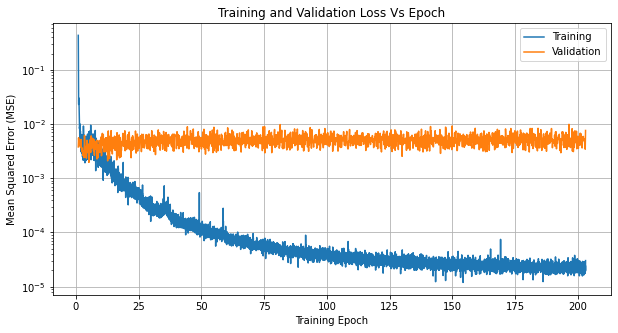

In [7]:
MLP1.train(n_epochs=500, verbose=50, plot=True)

Best prediction: 124, Worst prediction: 24


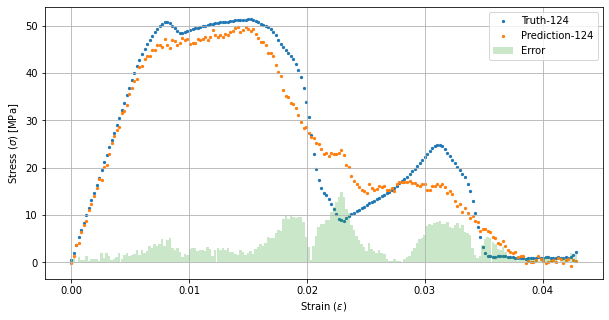

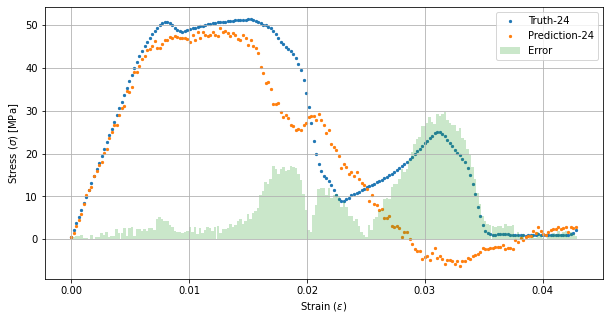

In [8]:
MLP1.predict(stand=True, plot=True)

# MLP Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Version 1
$[x_i, y_i] \to \delta x_i$  
$[x_i, y_i] \to \delta y_i$

In [9]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [10]:
DAT.train_in1.shape, DAT.dx_out1.shape

((450, 2), (353, 450, 1))

In [11]:
in_size = DAT.train_in1.shape[-1]
out_size = DAT.dx_out1.shape[-1]
h_size = [10, 100, 100, 10]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3

In [12]:
trainDSx = Dataset_(DAT.train_in1, DAT.dx_out1[0])
trainDSy = Dataset_(DAT.train_in1, DAT.dy_out1[0])

trainx_dataloader = DataLoader(dataset=trainDSx, batch_size=BATCH_SIZE, shuffle=True)
trainy_dataloader = DataLoader(dataset=trainDSy, batch_size=BATCH_SIZE, shuffle=True)

testx_dataloader = DataLoader(dataset=trainDSx, batch_size=BATCH_SIZE, shuffle=False)
testy_dataloader = DataLoader(dataset=trainDSy, batch_size=BATCH_SIZE, shuffle=False)

train_dataloader = trainx_dataloader
test_dataloader = testx_dataloader

In [13]:
MLP2 = MODEL(
    typ="MLP",
    model=MLP(in_size, h_size, out_size).to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.25, 10, 1e-4, True), 
    earlyStop=EarlyStopping(patience=25, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

summary(MLP2.model, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 1]                    --
├─Linear: 1-1                            [1, 10]                   30
├─ModuleList: 1-2                        --                        --
│    └─mlpBlock: 2-5                     --                        (recursive)
│    │    └─Sigmoid: 3-1                 [1, 10]                   --
│    └─mlpBlock: 2-2                     [1, 100]                  --
│    │    └─Linear: 3-2                  [1, 100]                  1,100
│    └─mlpBlock: 2-5                     --                        (recursive)
│    │    └─Sigmoid: 3-3                 [1, 100]                  --
│    └─mlpBlock: 2-4                     [1, 100]                  --
│    │    └─Linear: 3-4                  [1, 100]                  10,100
│    └─mlpBlock: 2-5                     --                        (recursive)
│    │    └─Sigmoid: 3-5                 [1, 100]  

Epoch: 1 - Loss: 0.28024744987487793
Epoch: 50 - Loss: 0.0979008600115776
Epoch: 100 - Loss: 1.4262820482254028
Best Epoch: 72, with loss 6.34490334050497e-07


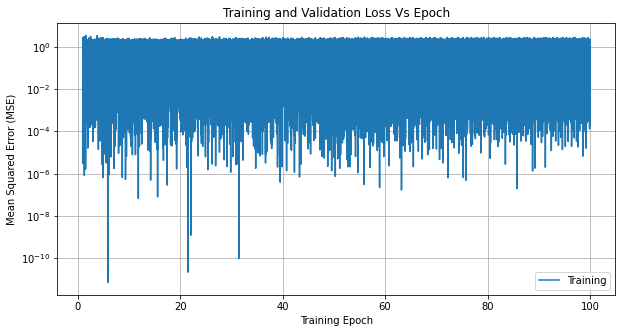

In [14]:
MLP2.train(n_epochs=100, verbose=50, plot=True)

In [15]:
MLP2.predict(stand=False, plot=False)

Best prediction: 208, Worst prediction: 128


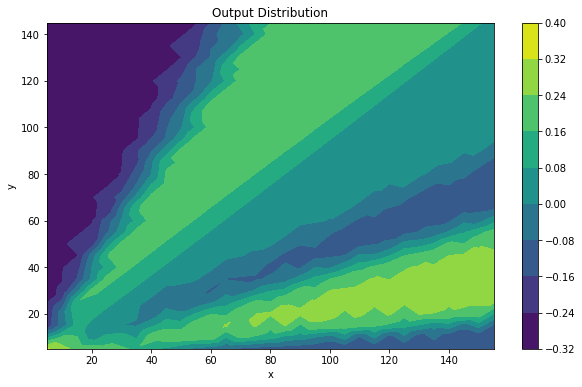

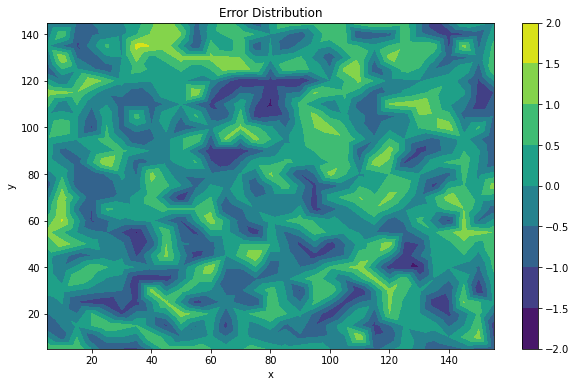

In [16]:
plot_Distribution(MLP2.data.train_in1, MLP2.test_outputs[:,0], truth=None, typ="contour")
plot_Distribution(MLP2.data.train_in1, MLP2.test_outputs[:,0], truth=MLP2.truth[:,0], typ="contour")

### Version 2
$[x_1, y_2, ..., x_n, y_n] \to [\delta x_i, ..., \delta x_n]$  
$[x_1, y_2, ..., x_n, y_n] \to [\delta y_i, ..., \delta y_n]$


In [17]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [18]:
in_size = DAT.train_in2.shape[-1]
out_size = DAT.dx_out2.shape[-1]
h_size = []

BATCH_SIZE = 1
LEARNING_RATE = 1e-3

In [19]:
trainDSx = Dataset_(DAT.train_in2, DAT.dx_out2[0])
trainDSy = Dataset_(DAT.train_in2, DAT.dy_out2[0])

trainx_dataloader = DataLoader(dataset=trainDSx, batch_size=BATCH_SIZE, shuffle=True)
trainy_dataloader = DataLoader(dataset=trainDSy, batch_size=BATCH_SIZE, shuffle=True)

testx_dataloader = DataLoader(dataset=trainDSx, batch_size=BATCH_SIZE, shuffle=False)
testy_dataloader = DataLoader(dataset=trainDSy, batch_size=BATCH_SIZE, shuffle=False)

train_dataloader = trainx_dataloader
test_dataloader = testx_dataloader

In [20]:
MLP3 = MODEL(
    typ="MLP",
    model=MLP(in_size, h_size, out_size).to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=test_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.25, 16, 1e-4, True), 
    earlyStop=EarlyStopping(patience=500, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

summary(MLP3.model, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 450]                  --
├─Linear: 1-1                            [1, 450]                  405,450
Total params: 405,450
Trainable params: 405,450
Non-trainable params: 0
Total mult-adds (M): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 1.62
Estimated Total Size (MB): 1.63

Epoch: 1 - Loss: 2842.296142578125
Epoch: 50 - Loss: 7.942633152008057
Epoch: 100 - Loss: 0.537101149559021
Epoch: 150 - Loss: 0.11380141228437424
Epoch: 200 - Loss: 0.0028250946197658777
Epoch: 250 - Loss: 0.00010410630056867376
Epoch: 300 - Loss: 1.1040656033856067e-07
Epoch: 350 - Loss: 2.390294850940222e-09
Epoch: 400 - Loss: 4.312658841154615e-10
Epoch: 450 - Loss: 8.181549188135406e-12
Epoch: 500 - Loss: 6.266939658189363e-12
Epoch: 550 - Loss: 2.5017128126025856e-12
Epoch: 600 - Loss: 2.123493004699273e-12
Epoch: 650 - Loss: 1.8631504759142326e-12
Epoch: 700 - Loss: 2.0730919151473737e-12
Epoch: 750 - Loss: 1.8298021518120544e-12
Early stopping triggered after 500 epochs without improvement.
Best Epoch: 749, with loss 1.7022202874680814e-12


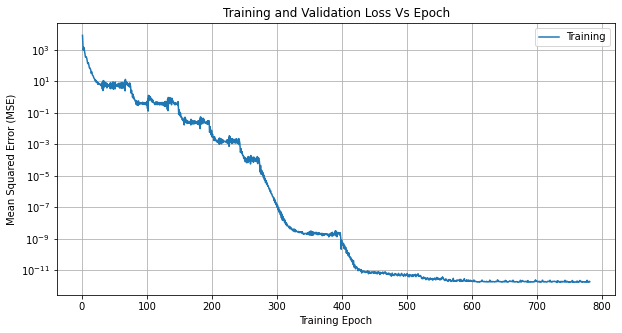

In [21]:
MLP3.train(n_epochs=1000, verbose=50, plot=True)

In [22]:
MLP3.predict(stand=False, plot=False)

Best prediction: 0, Worst prediction: 0


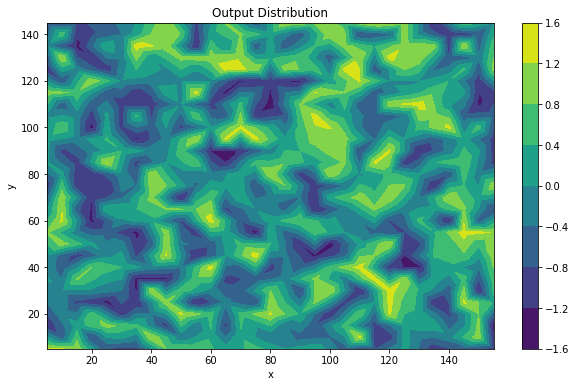

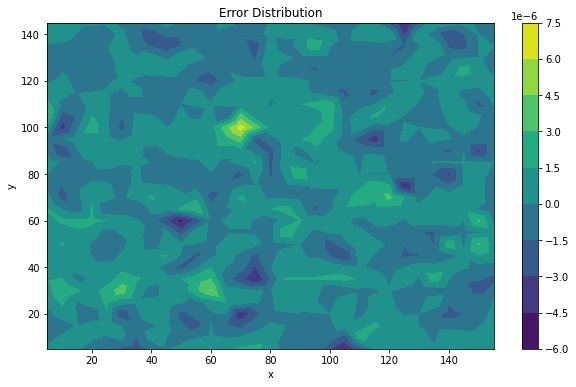

In [23]:
plot_Distribution(MLP3.data.train_in1, MLP3.test_outputs[0], truth=None, typ="contour")
plot_Distribution(MLP3.data.train_in1, MLP3.test_outputs[0], truth=MLP3.truth[0], typ="contour")

In [24]:
for name, param in MLP3.model.state_dict().items():
    print(f"{name}: {param.shape}\n{param}\nTotal params: {param.numel()}\n")

fcOUT.weight: torch.Size([450, 900])
tensor([[-0.0382,  0.0298, -0.0055,  ...,  0.0005, -0.0050,  0.0538],
        [ 0.0514,  0.0317,  0.0170,  ..., -0.0280,  0.0177,  0.0043],
        [-0.0217,  0.0550,  0.0834,  ...,  0.0386, -0.0139, -0.0182],
        ...,
        [ 0.0525,  0.0157,  0.0564,  ..., -0.0561,  0.0395, -0.0510],
        [-0.0323, -0.0457, -0.0107,  ..., -0.0035, -0.0002, -0.0034],
        [ 0.0304,  0.0335,  0.0621,  ..., -0.0074,  0.0276, -0.0009]])
Total params: 405000

fcOUT.bias: torch.Size([450])
tensor([0.0113, 0.0100, 0.0102, 0.0116, 0.0088, 0.0104, 0.0095, 0.0079, 0.0112,
        0.0098, 0.0076, 0.0102, 0.0115, 0.0096, 0.0079, 0.0125, 0.0094, 0.0111,
        0.0104, 0.0108, 0.0094, 0.0101, 0.0095, 0.0081, 0.0102, 0.0093, 0.0100,
        0.0095, 0.0091, 0.0128, 0.0104, 0.0103, 0.0101, 0.0091, 0.0097, 0.0102,
        0.0068, 0.0088, 0.0078, 0.0100, 0.0115, 0.0111, 0.0088, 0.0129, 0.0095,
        0.0104, 0.0087, 0.0093, 0.0108, 0.0100, 0.0081, 0.0097, 0.0125, 0.011